<a href="https://colab.research.google.com/github/Nirmiteep/Intelligent-Job-Market-Analysis-and-Fraud-Detection-System/blob/main/jobs2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LOAD THE DATA AND MERGE ALL THE CSV FILES


In [ ]:
# =========================================================
# STEP 1: LOAD DATASETS
# =========================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
df_fake = pd.read_csv("fake_job_postings.csv")
df_india = pd.read_csv("indian_job_market_2000.csv")
df_naukri = pd.read_csv("NaukriData_Data Science.csv")
df_salary = pd.read_csv("ds_salaries.csv")

In [ ]:
# ---------- STANDARDIZE STRUCTURE ----------
#DATA INTEGRATION (WAREHOUSING)
# Fake
df_fake_clean = pd.DataFrame({
    'title': df_fake['title'],
    'description': df_fake['description'],
    'requirements': df_fake['requirements'],
    'company_profile': df_fake['company_profile'],
    'salary_range': df_fake['salary_range'],
    'fraudulent': df_fake['fraudulent'],
    'source': 'fake'
})

# India
df_india_clean = pd.DataFrame({
    'title': df_india['job_title'],
    'description': df_india['description'],
    'requirements': df_india['skills'],
    'company_profile': df_india['company'],
    'salary_range': df_india['salary'],
    'fraudulent': -1,
    'source': 'india'
})

# Naukri
df_naukri_clean = pd.DataFrame({
    'title': df_naukri['Job_Titles'],
    'description': df_naukri['Skills'],
    'requirements': df_naukri['Skills'],
    'company_profile': df_naukri['Company_Names'],
    'salary_range': df_naukri['Package_Details'],
    'fraudulent': -1,
    'source': 'naukri'
})

# Salary
df_salary_clean = pd.DataFrame({
    'title': df_salary['job_title'],
    'description': df_salary['job_title'],
    'requirements': df_salary['experience_level'],
    'company_profile': df_salary['company_location'],
    'salary_range': df_salary['salary_in_usd'],
    'fraudulent': -1,
    'source': 'salary'
})

# Merge (DATA WAREHOUSE)
df_final = pd.concat([
    df_fake_clean,
    df_india_clean,
    df_naukri_clean,
    df_salary_clean
], ignore_index=True)

**🔴 CURRENT DATA ISSUES (DON’T IGNORE)
1. Missing values (serious)
title → ~13k missing
description → ~9k missing
company_profile → ~14k missing
salary_range → ~23k missing

👉 If you don’t fix this now, everything downstream becomes garbage.

2. Fraud imbalance (expected but dangerous)
Fraud = 866
Real = 17k
Unknown = ~50k

👉 You cannot treat all rows equally.

3. Dataset dominance
Naukri = 47k (dominates everything)

👉 This will bias your skill analysis.**

# STEP 2: PREPROCESSING

In [ ]:
# Missing values
df_final = df_final.fillna("unknown")

# Normalize text
cols = ['title', 'description', 'requirements', 'company_profile']
for col in cols:
    df_final[col] = df_final[col].astype(str).str.lower().str.strip()

# Remove weak data
df_final = df_final[df_final['description'] != "unknown"]
df_final = df_final[df_final['description'].str.len() > 30]

# Remove duplicates
df_final = df_final.drop_duplicates()

# Feature engineering
df_final['desc_length'] = df_final['description'].apply(len)

# Clip outliers
upper = df_final['desc_length'].quantile(0.99)
df_final['desc_length'] = df_final['desc_length'].clip(upper=upper)

# Working datasets
df_analysis = df_final[df_final['source'] != 'salary']
df_labeled = df_analysis[df_analysis['fraudulent'] != -1]

Data preprocessing techniques such as missing value imputation, noise removal, data integration, data transformation, aggregation, and discretization were implemented. Redundancy was handled by removing duplicate records, and basic correlation analysis was performed. Advanced techniques like PCA and wavelet transforms were not applied as the dataset does not require high-dimensional reduction.


# DATA MINING

Helper Functions

In [ ]:
import re

def missing_info(row):
    return sum([
        row['salary_range'] == "unknown",
        row['company_profile'] == "unknown",
        row['requirements'] == "unknown"
    ])

def weak_description(row):
    return 1 if len(row['description']) < 50 else 0

def poor_text(row):
    text = row['description']
    ratio = len(re.findall(r'[^a-zA-Z]', text)) / max(len(text), 1)
    return 1 if ratio > 0.3 else 0

def scam_language(row):
    keywords = ["easy money", "quick earning", "no experience", "work from home"]
    return 1 if any(k in row['description'] for k in keywords) else 0

def weak_company(row):
    return 1 if row['company_profile'] == "unknown" else 0

def missing_contact(row):
    text = row['description']
    return 1 if ("@" not in text and "www" not in text) else 0

def unrealistic_offer(row):
    keywords = ["high salary", "easy job"]
    return 1 if any(k in row['description'] for k in keywords) else 0

def structural_issue(row):
    return sum([
        row['description'] == "unknown",
        row['requirements'] == "unknown",
        row['company_profile'] == "unknown"
    ]) >= 2

def anomaly(row):
    return 1 if len(row['description']) < 30 else 0

STEP 4: FRAUD RULE ENGINE (MINING)

In [ ]:
import re

def missing_info(row):
    return sum([
        row['salary_range'] == "unknown",
        row['company_profile'] == "unknown",
        row['requirements'] == "unknown"
    ])

def weak_description(row):
    return 1 if len(row['description']) < 50 else 0

def poor_text(row):
    text = row['description']
    ratio = len(re.findall(r'[^a-zA-Z]', text)) / max(len(text), 1)
    return 1 if ratio > 0.3 else 0

def scam_language(row):
    keywords = ["easy money", "quick earning", "no experience", "work from home"]
    return 1 if any(k in row['description'] for k in keywords) else 0

def weak_company(row):
    return 1 if row['company_profile'] == "unknown" else 0

def missing_contact(row):
    text = row['description']
    return 1 if ("@" not in text and "www" not in text) else 0

def unrealistic_offer(row):
    keywords = ["high salary", "easy job"]
    return 1 if any(k in row['description'] for k in keywords) else 0

def structural_issue(row):
    return sum([
        row['description'] == "unknown",
        row['requirements'] == "unknown",
        row['company_profile'] == "unknown"
    ]) >= 2

def anomaly(row):
    return 1 if len(row['description']) < 30 else 0

STEP 5: WEIGHTED RISK MODEL

In [ ]:
def risk_score(row):
    score = 0

    score += 2 * missing_info(row)
    score += 2 * weak_company(row)

    score += weak_description(row)
    score += poor_text(row)
    score += scam_language(row)
    score += missing_contact(row)

    score += unrealistic_offer(row)
    score += structural_issue(row)
    score += anomaly(row)

    return score

df_analysis['risk_score'] = df_analysis.apply(risk_score, axis=1)

clasification

In [ ]:
def classify(score):
    if score >= 6:
        return "High Risk"
    elif score >= 3:
        return "Moderate Risk"
    else:
        return "Low Risk"

df_analysis['risk_level'] = df_analysis['risk_score'].apply(classify)

EVALUATION metrices

In [ ]:
from sklearn.metrics import *

THRESHOLD = 4

# CREATE ONCE
df_labeled['predicted'] = df_labeled.apply(
    lambda row: 1 if risk_score(row) >= THRESHOLD else 0,
    axis=1
)

# Metrics
print("Accuracy:", (df_labeled['predicted'] == df_labeled['fraudulent']).mean())

print("\nConfusion Matrix:\n", confusion_matrix(df_labeled['fraudulent'], df_labeled['predicted']))

print("\nClassification Report:\n", classification_report(df_labeled['fraudulent'], df_labeled['predicted']))

print("\nBalanced Accuracy:", balanced_accuracy_score(df_labeled['fraudulent'], df_labeled['predicted']))

Accuracy: 0.7168096920747098

Confusion Matrix:
 [[10886  4257]
 [  231   474]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.72      0.83     15143
           1       0.10      0.67      0.17       705

    accuracy                           0.72     15848
   macro avg       0.54      0.70      0.50     15848
weighted avg       0.94      0.72      0.80     15848


Balanced Accuracy: 0.6956102180489265


STEP 8: SKILL DEMAND (FIXED EXTRACTION)

In [ ]:
skill_patterns = {
    "python": [" python "],
    "sql": [" sql "],
    "excel": [" excel "],
    "machine learning": ["machine learning"],
    "java": [" java "],
    "data science": ["data science"]
}

def extract_skills(text):
    text = " " + str(text) + " "
    found = []
    for skill, variants in skill_patterns.items():
        if any(v in text for v in variants):
            found.append(skill)
    return found

df_analysis['skills'] = df_analysis['description'].apply(extract_skills)

STEP 9: CLUSTERING (K-MEANS)

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
df_analysis['cluster'] = kmeans.fit_predict(df_analysis[['desc_length']])

df_analysis['job_group'] = pd.cut(
    df_analysis['desc_length'],
    bins=3,
    labels=["Low Detail", "Medium Detail", "High Detail"]
)

🔥 STEP 10: VISUALIZATION (FIXED & MEANINGFUL)

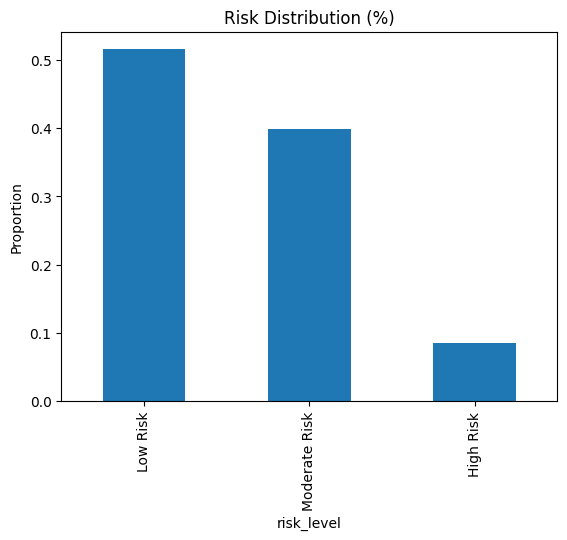

In [ ]:
#✔ Risk Distribution
df_analysis['risk_level'].value_counts(normalize=True).plot(kind='bar')
plt.title("Risk Distribution (%)")
plt.ylabel("Proportion")
plt.show()

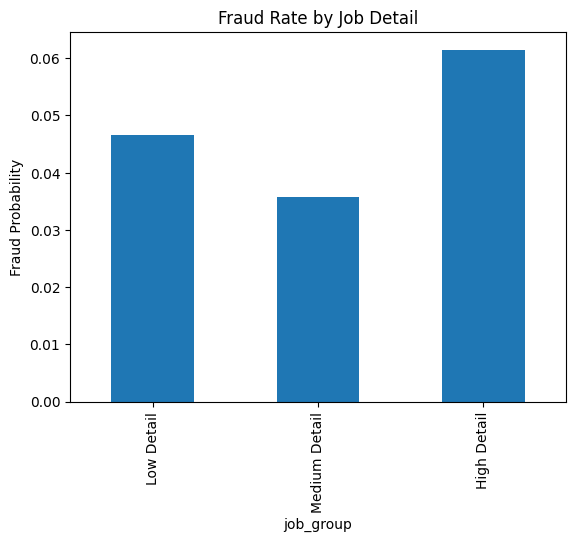

In [ ]:
#raud by Job Detail (IMPORTANT DECISION GRAPH)
df_labeled = df_analysis[df_analysis['fraudulent'] != -1]

fraud_rate = df_labeled.groupby('job_group')['fraudulent'].mean()

fraud_rate.plot(kind='bar')
plt.title("Fraud Rate by Job Detail")
plt.ylabel("Fraud Probability")
plt.show()

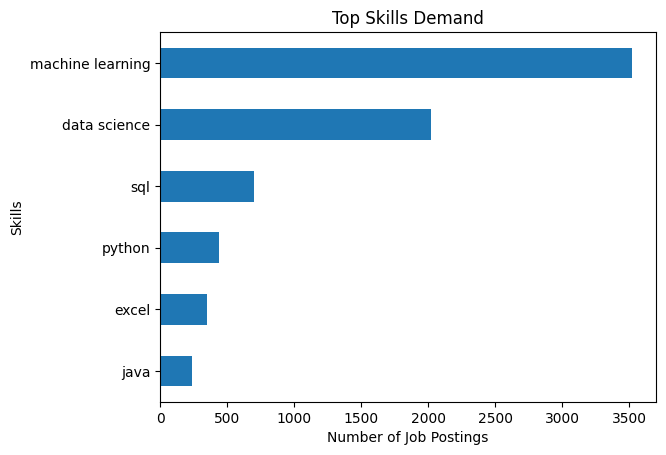

In [ ]:
skill_counts = df_analysis['skills'].explode().value_counts()

skill_counts = skill_counts.sort_values()  # better for barh

skill_counts.plot(kind='barh')

plt.title("Top Skills Demand")
plt.xlabel("Number of Job Postings")   # FIXED
plt.ylabel("Skills")                   # FIXED

plt.show()

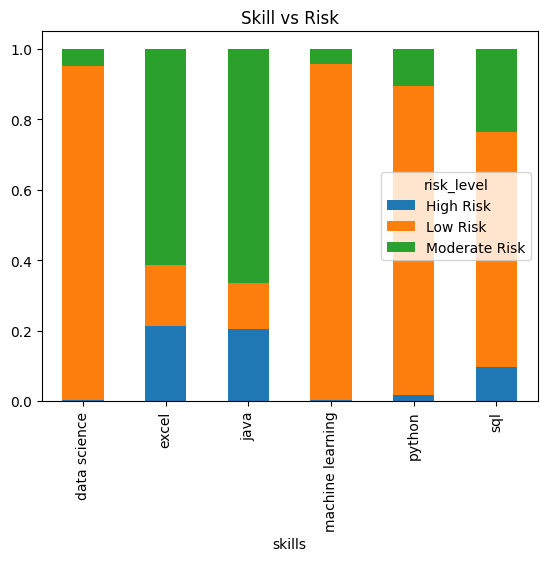

In [ ]:
import matplotlib.pyplot as plt

#✔ Skill vs Risk
exploded_df = df_analysis.explode('skills')
table = pd.crosstab(
    exploded_df['skills'],
    exploded_df['risk_level'],
    normalize='index'
)

table.plot(kind='bar', stacked=True)
plt.title("Skill vs Risk")
plt.show()

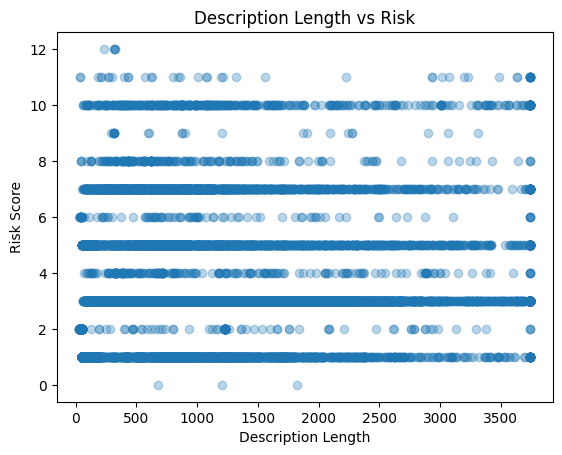

In [ ]:
#✔ Description vs Risk
plt.scatter(df_analysis['desc_length'], df_analysis['risk_score'], alpha=0.3)
plt.title("Description Length vs Risk")
plt.xlabel("Description Length")
plt.ylabel("Risk Score")
plt.show()

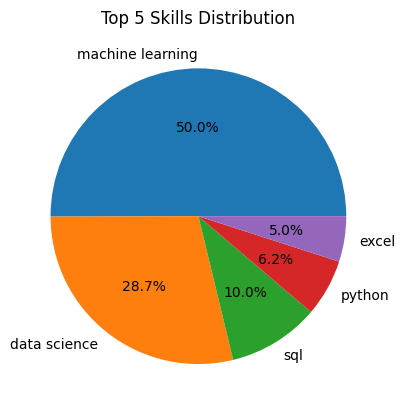

In [ ]:
top5 = df_analysis['skills'].explode().value_counts().head(5)

top5.plot(kind='pie', autopct='%1.1f%%')

plt.title("Top 5 Skills Distribution")
plt.ylabel("")  # remove useless label

plt.show()

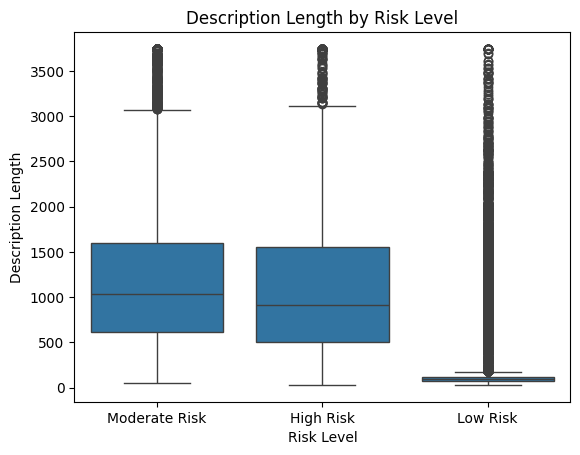

In [ ]:
sns.boxplot(x='risk_level', y='desc_length', data=df_analysis)

plt.title("Description Length by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Description Length")
plt.show()

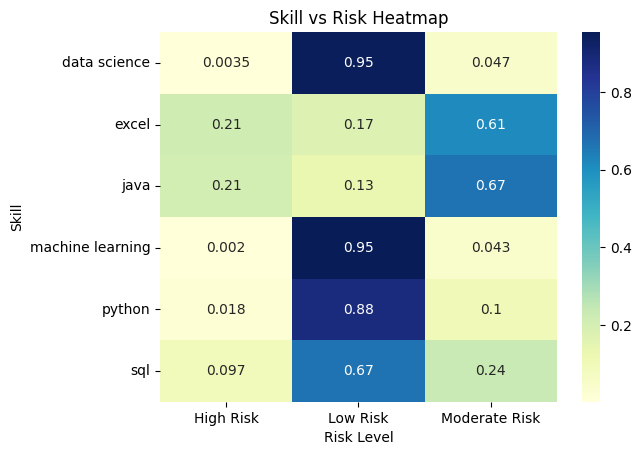

In [ ]:
sns.heatmap(table, annot=True, cmap="YlGnBu")

plt.title("Skill vs Risk Heatmap")
plt.xlabel("Risk Level")
plt.ylabel("Skill")
plt.show()

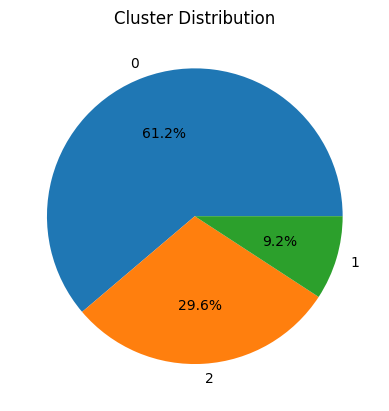

In [ ]:
df_analysis['cluster'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Cluster Distribution")
plt.ylabel("")
plt.show()

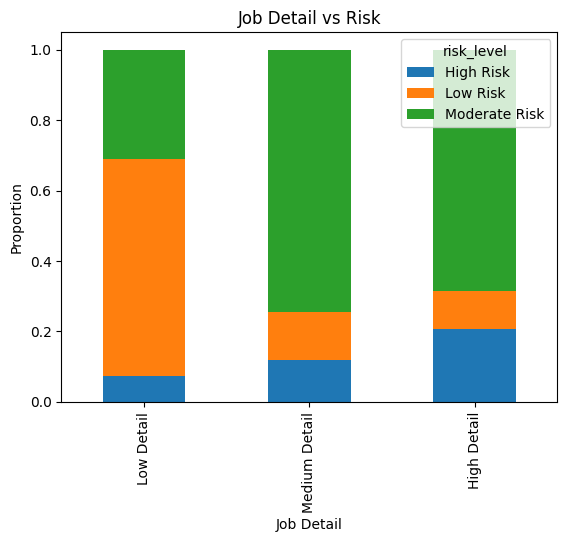

In [ ]:
group_risk = pd.crosstab(
    df_analysis['job_group'],
    df_analysis['risk_level'],
    normalize='index'
)

group_risk.plot(kind='bar', stacked=True)

plt.title("Job Detail vs Risk")
plt.xlabel("Job Detail")
plt.ylabel("Proportion")
plt.show()

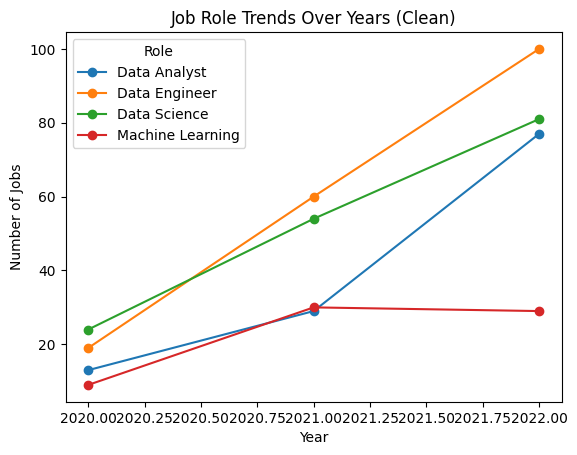

In [ ]:
def map_role(title):
    title = str(title).lower()

    if "machine learning" in title or "ml" in title:
        return "Machine Learning"
    elif "data scientist" in title:
        return "Data Science"
    elif "analyst" in title:
        return "Data Analyst"
    elif "engineer" in title:
        return "Data Engineer"
    else:
        return "Other"

df_salary['role_group'] = df_salary['job_title'].apply(map_role)
trend = df_salary.groupby(['work_year', 'role_group']).size().unstack().fillna(0)
trend = trend.drop(columns=['Other'], errors='ignore')
trend.plot(marker='o')

plt.title("Job Role Trends Over Years (Clean)")
plt.xlabel("Year")
plt.ylabel("Number of Jobs")
plt.legend(title="Role")

plt.show()

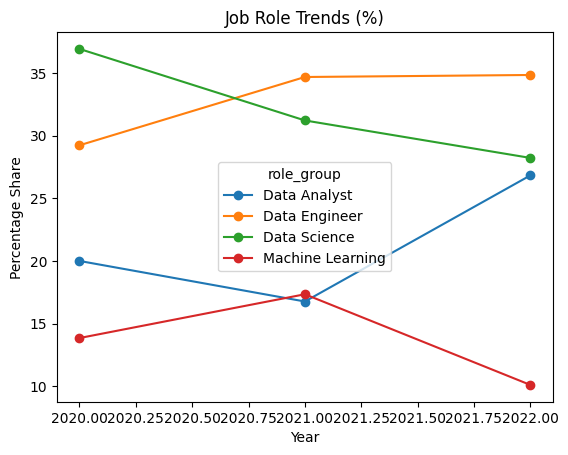

In [ ]:
trend_pct = trend.div(trend.sum(axis=1), axis=0) * 100

trend_pct.plot(marker='o')

plt.title("Job Role Trends (%)")
plt.xlabel("Year")
plt.ylabel("Percentage Share")

plt.show()

In [ ]:
pd.read_csv("fake_job_postings.csv")

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17875,17876,Account Director - Distribution,"CA, ON, Toronto",Sales,NaN,Vend is looking for some awesome new talent to...,Just in case this is the first time you’ve vis...,To ace this role you:Will eat comprehensive St...,What can you expect from us?We have an open cu...,0,1,1,Full-time,Mid-Senior level,NaN,Computer Software,Sales,0
17876,17877,Payroll Accountant,"US, PA, Philadelphia",Accounting,NaN,WebLinc is the e-commerce platform and service...,The Payroll Accountant will focus primarily on...,- B.A. or B.S. in Accounting- Desire to have f...,Health &amp; WellnessMedical planPrescription ...,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Internet,Accounting/Auditing,0
17877,17878,Project Cost Control Staff Engineer - Cost Con...,"US, TX, Houston",NaN,NaN,We Provide Full Time Permanent Positions for m...,Experienced Project Cost Control Staff Enginee...,At least 12 years professional experience.Abil...,NaN,0,0,0,Full-time,NaN,NaN,NaN,NaN,0
17878,17879,Graphic Designer,"NG, LA, Lagos",NaN,NaN,NaN,Nemsia Studios is looking for an experienced v...,1. Must be fluent in the latest versions of Co...,Competitive salary (compensation will be based...,0,0,1,Contract,Not Applicable,Professional,Graphic Design,Design,0


In [ ]:
df_final = pd.concat([
    df_fake_clean,
    df_india_clean,
    df_naukri_clean,
    df_salary_clean
], ignore_index=True)

In [ ]:
df_labeled

,title,description,requirements,company_profile,salary_range,fraudulent,source,desc_length,risk_score,risk_level,skills,cluster,job_group
0,marketing intern,"food52, a fast-growing, james beard award-winn...",experience with content management systems a m...,"we're food52, and we've created a groundbreaki...",unknown,0,fake,905.0,3,Moderate Risk,[],2,Low Detail
1,customer service - cloud video production,organised - focused - vibrant - awesome!do you...,what we expect from you:your key responsibilit...,"90 seconds, the worlds cloud video production ...",unknown,0,fake,2076.0,3,Moderate Risk,[],1,Medium Detail
2,commissioning machinery assistant (cma),"our client, located in houston, is actively se...",implement pre-commissioning and commissioning ...,valor services provides workforce solutions th...,unknown,0,fake,355.0,3,Moderate Risk,[],0,Low Detail
3,account executive - washington dc,the company: esri – environmental systems rese...,"education: bachelor’s or master’s in gis, busi...",our passion for improving quality of life thro...,unknown,0,fake,2600.0,3,Moderate Risk,[],1,High Detail
4,bill review manager,job title: itemization review managerlocation:...,qualifications:rn license in the state of texa...,spotsource solutions llc is a global human cap...,unknown,0,fake,1519.0,3,Moderate Risk,[],2,Medium Detail
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17874,javascript developer,"sr, javascript developer experience : 4-10 yea...",unknown,unknown,80000-100000,0,fake,474.0,8,High Risk,[sql],0,Low Detail
17875,account director - distribution,just in case this is the first time you’ve vis...,to ace this role you:will eat comprehensive st...,vend is looking for some awesome new talent to...,unknown,0,fake,1440.0,3,Moderate Risk,[],2,Medium Detail
17876,payroll accountant,the payroll accountant will focus primarily on...,- b.a. or b.s. in accounting- desire to have f...,weblinc is the e-commerce platform and service...,unknown,0,fake,1214.0,3,Moderate Risk,[],2,Low Detail
17877,project cost control staff engineer - cost con...,experienced project cost control staff enginee...,at least 12 years professional experience.abil...,we provide full time permanent positions for m...,unknown,0,fake,1290.0,3,Moderate Risk,[],2,Medium Detail


In [ ]:
df_analysis

,title,description,requirements,company_profile,salary_range,fraudulent,source,desc_length,risk_score,risk_level,skills,cluster,job_group
0,marketing intern,"food52, a fast-growing, james beard award-winn...",experience with content management systems a m...,"we're food52, and we've created a groundbreaki...",unknown,0,fake,905.0,3,Moderate Risk,[],2,Low Detail
1,customer service - cloud video production,organised - focused - vibrant - awesome!do you...,what we expect from you:your key responsibilit...,"90 seconds, the worlds cloud video production ...",unknown,0,fake,2076.0,3,Moderate Risk,[],1,Medium Detail
2,commissioning machinery assistant (cma),"our client, located in houston, is actively se...",implement pre-commissioning and commissioning ...,valor services provides workforce solutions th...,unknown,0,fake,355.0,3,Moderate Risk,[],0,Low Detail
3,account executive - washington dc,the company: esri – environmental systems rese...,"education: bachelor’s or master’s in gis, busi...",our passion for improving quality of life thro...,unknown,0,fake,2600.0,3,Moderate Risk,[],1,High Detail
4,bill review manager,job title: itemization review managerlocation:...,qualifications:rn license in the state of texa...,spotsource solutions llc is a global human cap...,unknown,0,fake,1519.0,3,Moderate Risk,[],2,Medium Detail
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57874,unknown,data analysisdata scienceanalyticalpredictive ...,data analysisdata scienceanalyticalpredictive ...,celersoft,Unpaid,-1,naukri,109.0,1,Low Risk,[data science],0,Low Detail
57885,unknown,supply chainoperations researchnosqldata scien...,supply chainoperations researchnosqldata scien...,alliance data,Not disclosed,-1,naukri,82.0,1,Low Risk,"[machine learning, data science]",0,Low Detail
57890,unknown,text miningcareer developmentdata sciencefinan...,text miningcareer developmentdata sciencefinan...,g r infraprojects,18-22.5 Lacs PA,-1,naukri,100.0,1,Low Risk,"[machine learning, data science]",0,Low Detail
57894,unknown,data analysisedcrisk assessmentrisk modelingma...,data analysisedcrisk assessmentrisk modelingma...,coursera,Unpaid,-1,naukri,110.0,1,Low Risk,[machine learning],0,Low Detail


In [ ]:
df_salary

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,role_group
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L,Data Science
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S,Machine Learning
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M,Data Engineer
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S,Data Analyst
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L,Machine Learning
...,...,...,...,...,...,...,...,...,...,...,...,...,...
602,602,2022,SE,FT,Data Engineer,154000,USD,154000,US,100,US,M,Data Engineer
603,603,2022,SE,FT,Data Engineer,126000,USD,126000,US,100,US,M,Data Engineer
604,604,2022,SE,FT,Data Analyst,129000,USD,129000,US,0,US,M,Data Analyst
605,605,2022,SE,FT,Data Analyst,150000,USD,150000,US,100,US,M,Data Analyst


In [ ]:
df_analysis.to_csv("final_data.csv", index=False)

In [ ]:
print(df_analysis.columns)

Index(['title', 'description', 'requirements', 'company_profile',
       'salary_range', 'fraudulent', 'source', 'desc_length', 'risk_score',
       'risk_level', 'skills', 'cluster', 'job_group'],
      dtype='object')


In [ ]:
from google.colab import files
files.download("final_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>